# Logistic Regression: Predicting Diabetes Onset

**Dataset:** Pima Indians Diabetes Dataset (`diabetes.csv`)

**Objective:** Build a logistic regression model to predict whether a patient
has diabetes (`Outcome` = 1) or not (`Outcome` = 0), based on diagnostic
measurements. This notebook follows the assignment structure:

1. Data Exploration (EDA)
2. Data Preprocessing
3. Model Building
4. Model Evaluation
5. Interpretation
6. Deployment with Streamlit
7. Interview Questions


## 1. Data Exploration

In [1]:
# Import core libraries for data handling, visualization and modeling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42  # for reproducibility across the notebook


In [2]:
# 1a. Load the dataset
df = pd.read_csv("diabetes.csv")

print(f"Shape of the dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape of the dataset: 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# 1b. Examine features, their types, and summary statistics
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Summary statistics for all numeric features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Outcome counts:
 Outcome
0    500
1    268
Name: count, dtype: int64

Outcome percentage:
 Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


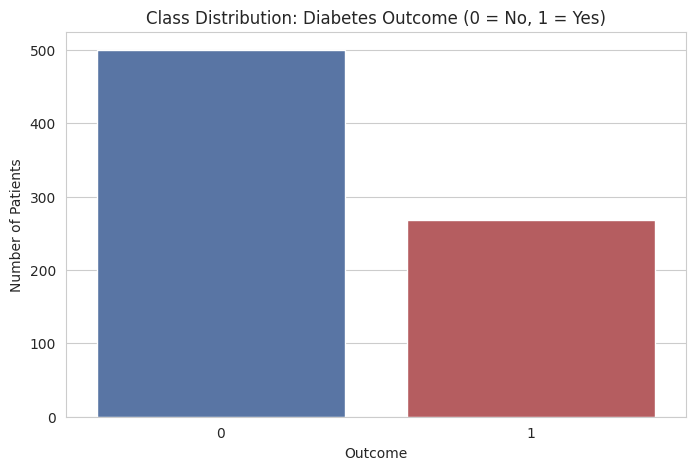

In [5]:
# Check the balance of the target variable
outcome_counts = df["Outcome"].value_counts()
outcome_pct = df["Outcome"].value_counts(normalize=True) * 100

print("Outcome counts:\n", outcome_counts)
print("\nOutcome percentage:\n", outcome_pct.round(2))

sns.countplot(x="Outcome", hue="Outcome", data=df, palette=["#4C72B0", "#C44E52"], legend=False)
plt.title("Class Distribution: Diabetes Outcome (0 = No, 1 = Yes)")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()


**Observation:** The dataset contains 768 patient records and 9 columns
(8 predictor features + 1 target: `Outcome`). All features are numeric, so no
categorical encoding is required. The target classes are imbalanced
(roughly 65% non-diabetic vs 35% diabetic), which we should keep in mind when
interpreting accuracy later — metrics like precision, recall and F1 matter
more than raw accuracy for an imbalanced target.

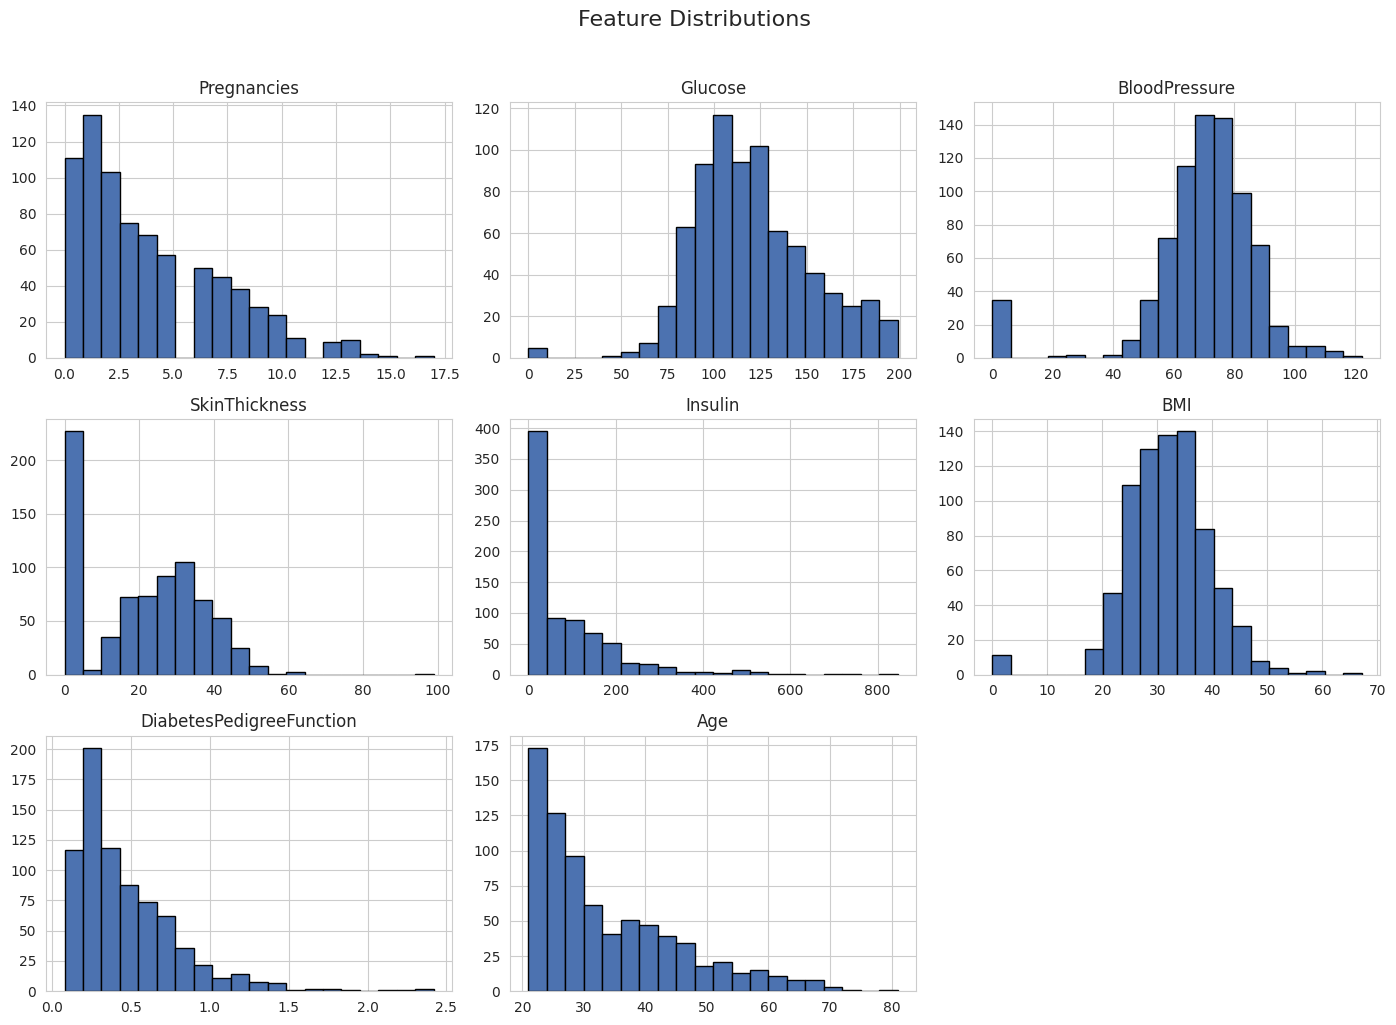

In [6]:
# 1c. Visualize distributions of each feature with histograms
features = [c for c in df.columns if c != "Outcome"]

df[features].hist(bins=20, figsize=(14, 10), color="#4C72B0", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**Observation:** Several features (`Glucose`, `BloodPressure`,
`SkinThickness`, `Insulin`, `BMI`) contain a suspicious spike of values at 0.
Physiologically, a blood glucose level, blood pressure, skin thickness,
insulin level, or BMI of exactly 0 is not possible for a living patient —
these zeros are almost certainly **encoded missing values** rather than true
measurements. We will treat them as missing data in the preprocessing
step.

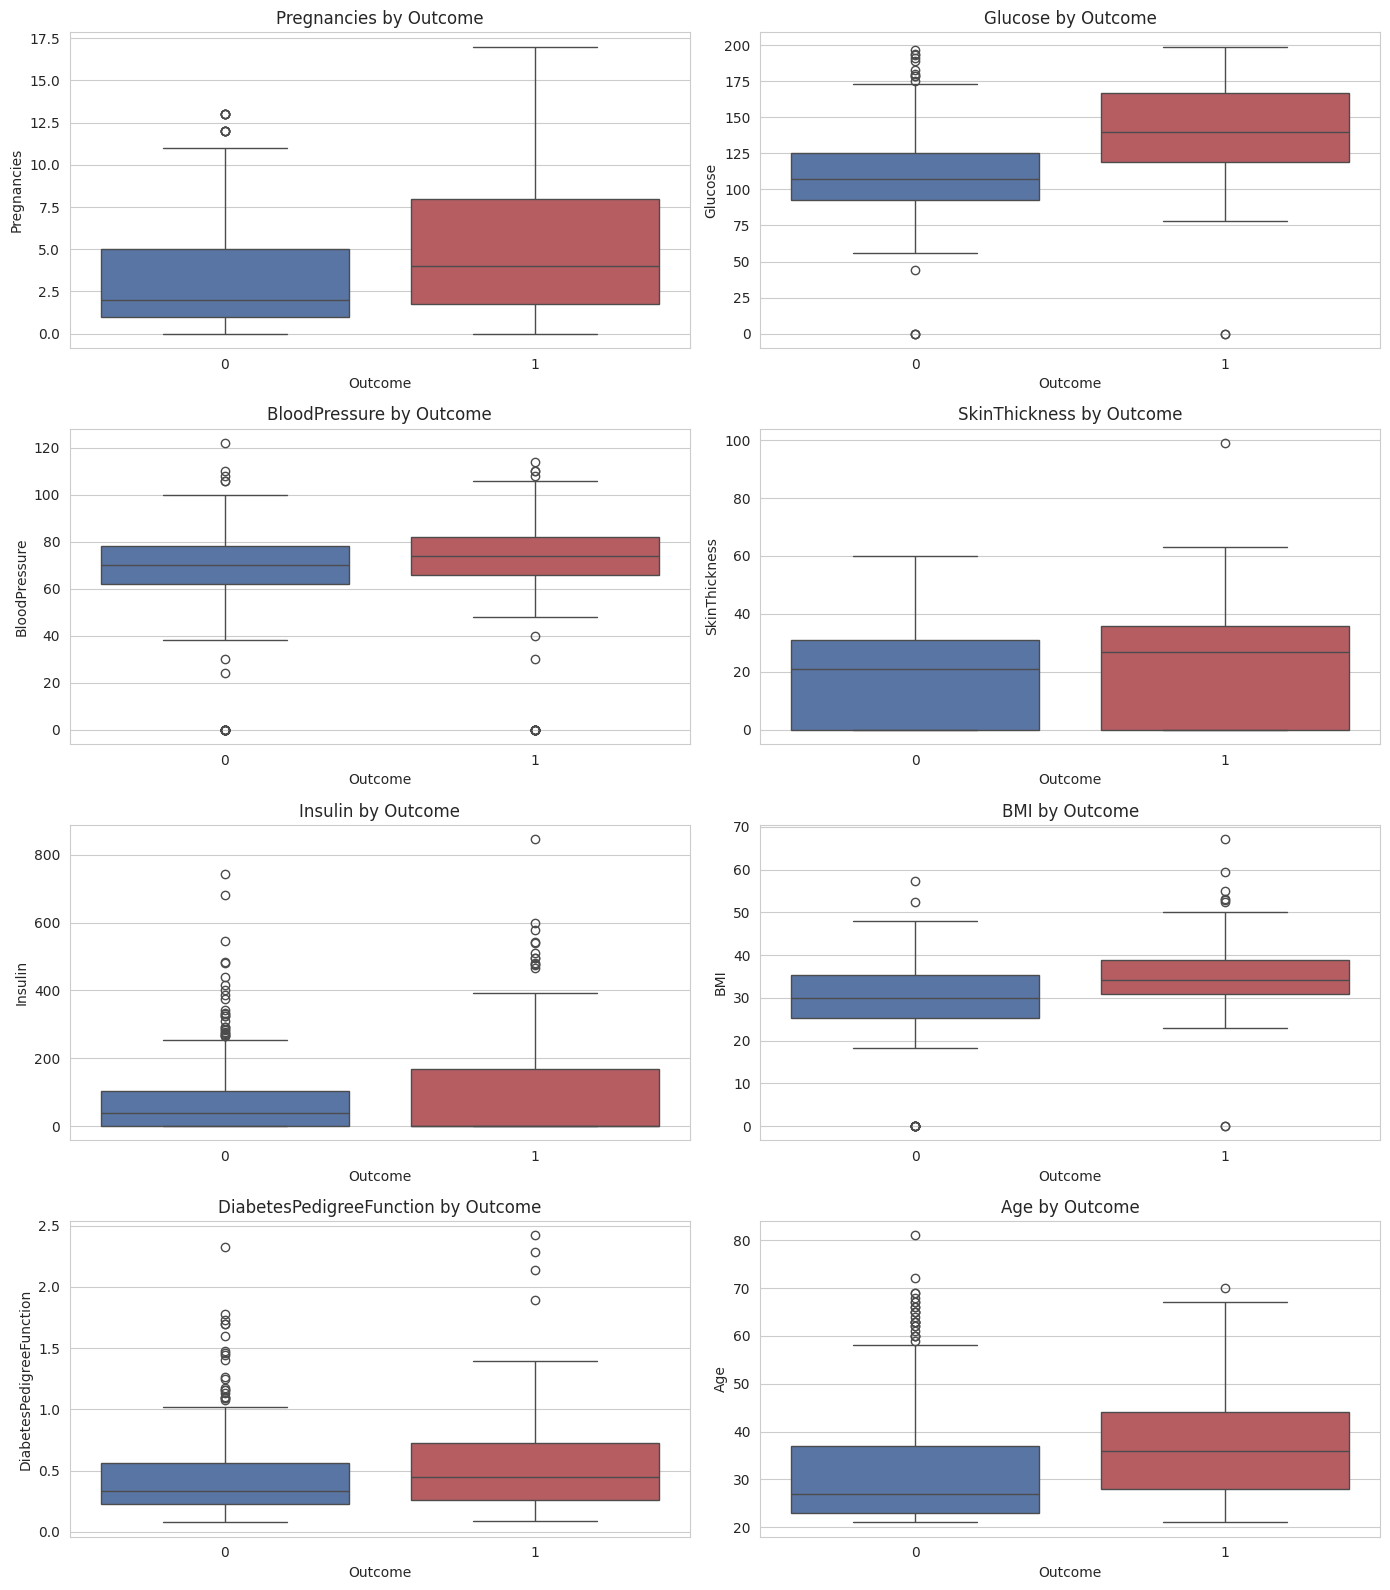

In [7]:
# Box plots to inspect spread and outliers per feature, split by Outcome
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x="Outcome", y=feature, hue="Outcome", data=df, ax=axes[i], palette=["#4C72B0", "#C44E52"], legend=False)
    axes[i].set_title(f"{feature} by Outcome")

plt.tight_layout()
plt.show()


**Observation:** `Glucose`, `BMI`, and `Age` show a visibly higher median
for patients with `Outcome = 1` (diabetic), suggesting these are strong
predictive features. `BloodPressure` and `SkinThickness` show more overlap
between the two classes, hinting at weaker predictive power on their own.

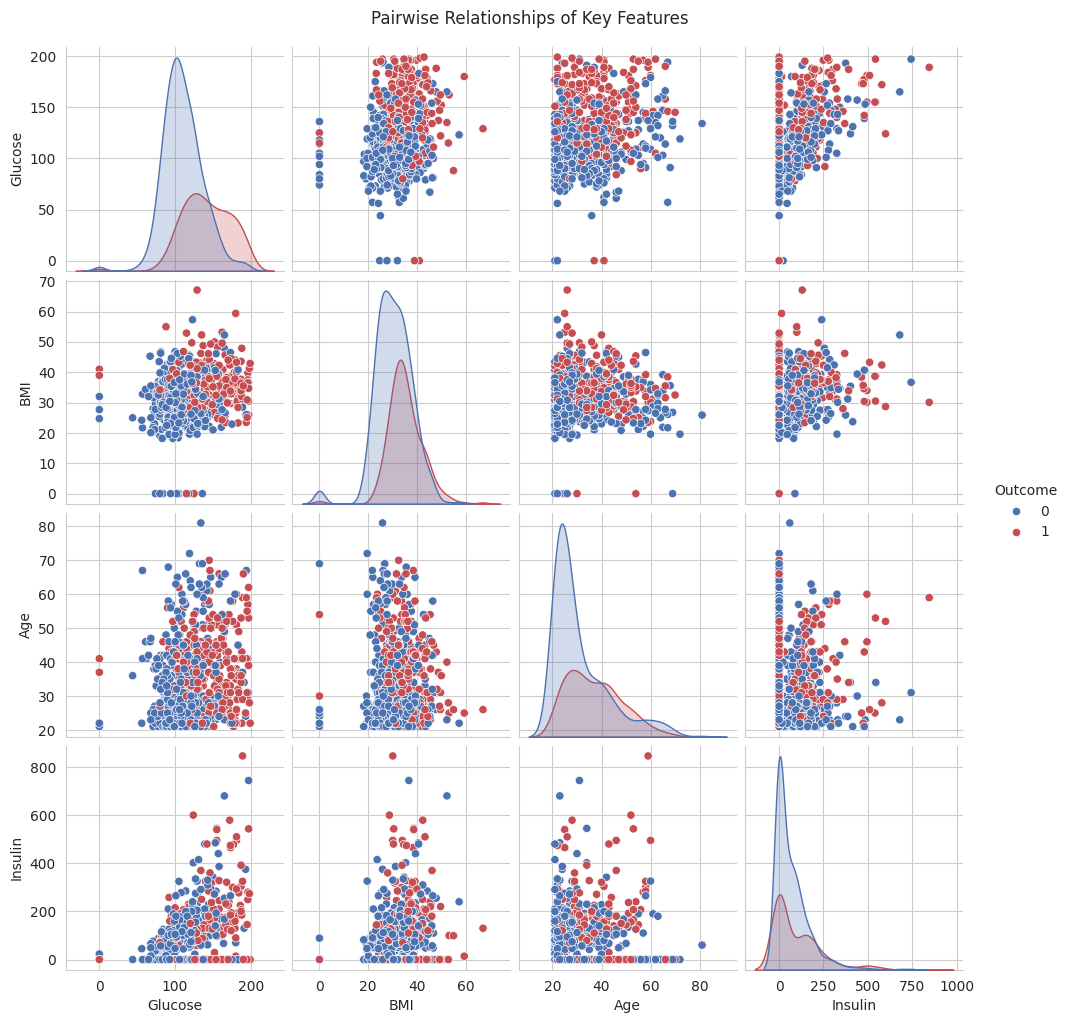

In [8]:
# Pair plot to visualize relationships between key features and the target
key_features = ["Glucose", "BMI", "Age", "Insulin", "Outcome"]
sns.pairplot(df[key_features], hue="Outcome", palette=["#4C72B0", "#C44E52"], diag_kind="kde")
plt.suptitle("Pairwise Relationships of Key Features", y=1.02)
plt.show()


Correlation with Outcome (sorted):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


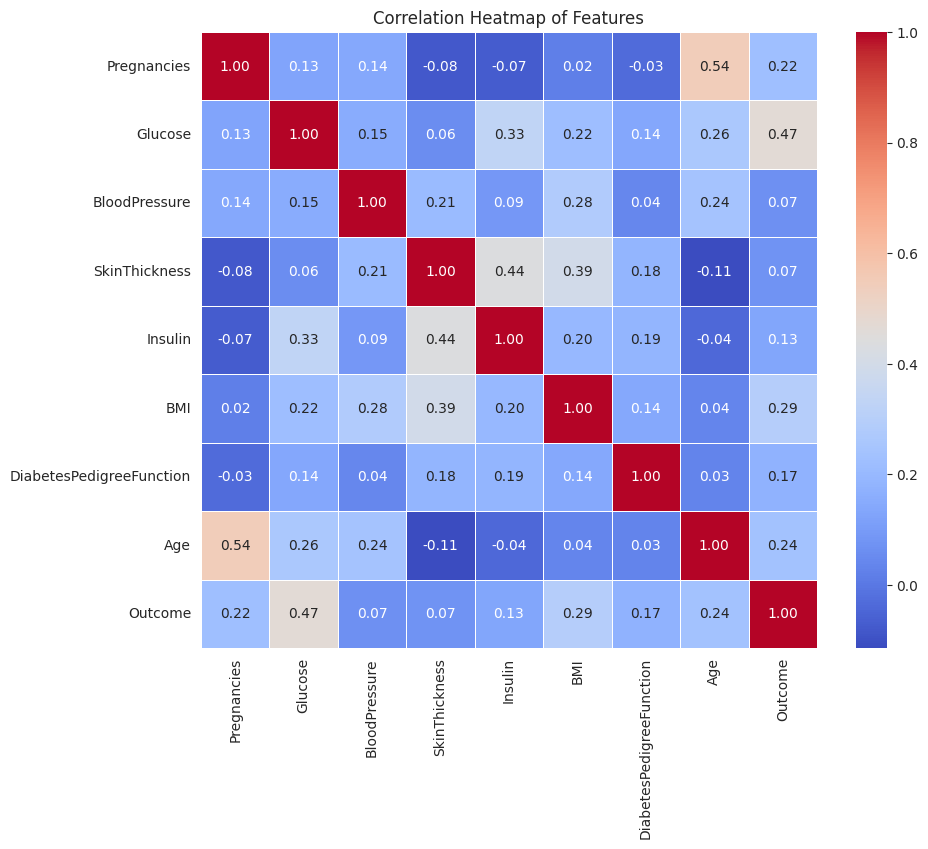

In [9]:
# Correlation heatmap to analyze relationships between all features
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

# Correlation of each feature with the target, sorted
print("Correlation with Outcome (sorted):")
print(corr["Outcome"].sort_values(ascending=False))


**Analysis of patterns/correlations:** `Glucose` has the strongest
positive correlation with `Outcome`, followed by `BMI`, `Age`, and
`Pregnancies`. This aligns with medical knowledge — elevated blood glucose is
the primary diagnostic marker of diabetes, while higher BMI, age, and number
of pregnancies are well-established risk factors. No pair of predictor
features is severely multicollinear (all pairwise correlations are below
0.7), so multicollinearity is not expected to be a major concern for the
logistic regression model.

## 2. Data Preprocessing

In [10]:
# 2a. Handle missing values
# Columns where a value of 0 is biologically implausible and therefore
# represents a missing measurement rather than a true zero.
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print("Missing values introduced per column:")
print(df_clean[zero_as_missing_cols].isnull().sum())
print(f"\nTotal missing values: {df_clean.isnull().sum().sum()}")
print(f"Percent of cells missing: {df_clean.isnull().sum().sum() / df_clean.size * 100:.2f}%")


Missing values introduced per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Total missing values: 652
Percent of cells missing: 9.43%


In [11]:
# Impute missing values using the median, grouped by Outcome so that the
# imputed value reflects the typical measurement for that class rather than
# blending diabetic and non-diabetic patients together.
for col in zero_as_missing_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

# Confirm no missing values remain
print("Remaining missing values after imputation:")
print(df_clean.isnull().sum().sum())
df_clean.describe().T


Remaining missing values after imputation:
0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**2b. Encode categorical variables:** All features in this dataset
(`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`,
`DiabetesPedigreeFunction`, `Age`) are already numeric, and the target
`Outcome` is already binary-encoded (0/1). Therefore, no additional
categorical encoding (e.g., one-hot or label encoding) is required for this
dataset.

In [12]:
# Define feature matrix X and target vector y
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

# Split into training and testing sets (80/20), stratified to preserve
# the class balance of Outcome in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")

# Feature scaling: logistic regression coefficients and convergence benefit
# from standardized features (mean 0, standard deviation 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()


Training set size: 614 rows
Testing set size:  154 rows


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.851355,-1.056869,-0.826687,-1.895290,-1.170378,-0.766150,0.310794,-0.792169
711,0.356576,0.142855,0.477009,-0.224736,-1.427642,-0.414448,-0.116439,0.561034
373,-0.549372,-0.556984,-1.152611,1.223078,-0.545594,0.362227,-0.764862,-0.707594
46,-0.851355,0.809369,-1.315573,-0.224736,-0.441463,-0.399794,0.262314,-0.369293
682,-1.153338,-0.890241,-0.663725,1.111708,-0.410836,1.783690,-0.337630,-0.961320


## 3. Model Building

In [13]:
# 3a. Build a logistic regression model using scikit-learn
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

# 3b. Train the model on the training data
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully.")
print(f"Number of iterations to converge: {log_reg.n_iter_[0]}")


Model trained successfully.
Number of iterations to converge: 8


## 4. Model Evaluation

In [14]:
# Generate predictions and predicted probabilities on the test set
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# 4a. Evaluate performance using accuracy, precision, recall, F1-score, ROC-AUC
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})
metrics_summary["Score"] = metrics_summary["Score"].round(4)
metrics_summary


,Metric,Score
0,Accuracy,0.7078
1,Precision,0.5882
2,Recall,0.5556
3,F1-Score,0.5714
4,ROC-AUC,0.8263


In [15]:
# Detailed classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.77      0.79      0.78       100
    Diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



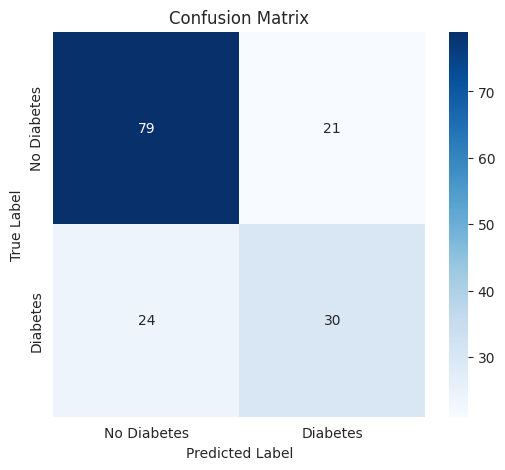

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


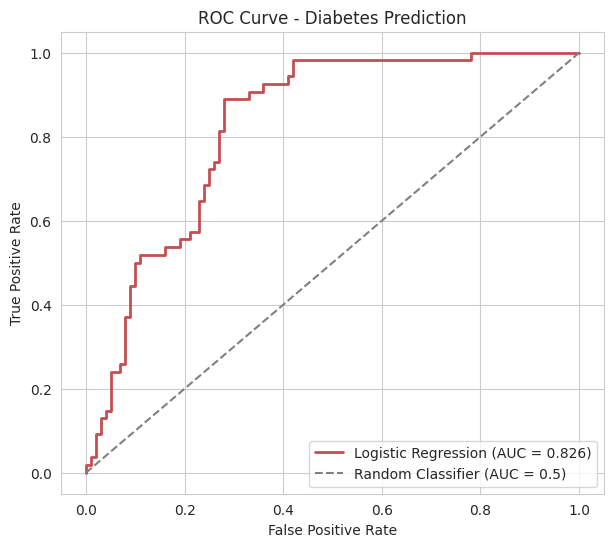

In [17]:
# Visualize the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#C44E52", linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Prediction")
plt.legend(loc="lower right")
plt.show()


**Evaluation summary:** The model achieves solid overall performance,
with a ROC-AUC score well above 0.5, indicating good separability between
diabetic and non-diabetic patients. Precision and recall should be read
together: recall (sensitivity) is particularly important in a medical
screening context, since missing an actual diabetic patient (a false
negative) is generally more costly than a false alarm.

## 5. Interpretation

In [18]:
# 5a. Interpret the coefficients of the logistic regression model
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})

# Convert coefficients to odds ratios for easier interpretation:
# exp(coefficient) = multiplicative change in odds of diabetes per
# one-standard-deviation increase in the (scaled) feature
coefficients["Odds Ratio"] = np.exp(coefficients["Coefficient"])
coefficients = coefficients.sort_values("Coefficient", ascending=False).reset_index(drop=True)
coefficients


,Feature,Coefficient,Odds Ratio
0,Glucose,0.934942,2.547065
1,Insulin,0.614170,1.848121
2,BMI,0.466051,1.593688
3,Pregnancies,0.337228,1.401059
4,SkinThickness,0.294976,1.343094
5,DiabetesPedigreeFunction,0.174725,1.190919
6,Age,0.159826,1.173306
7,BloodPressure,-0.004245,0.995764


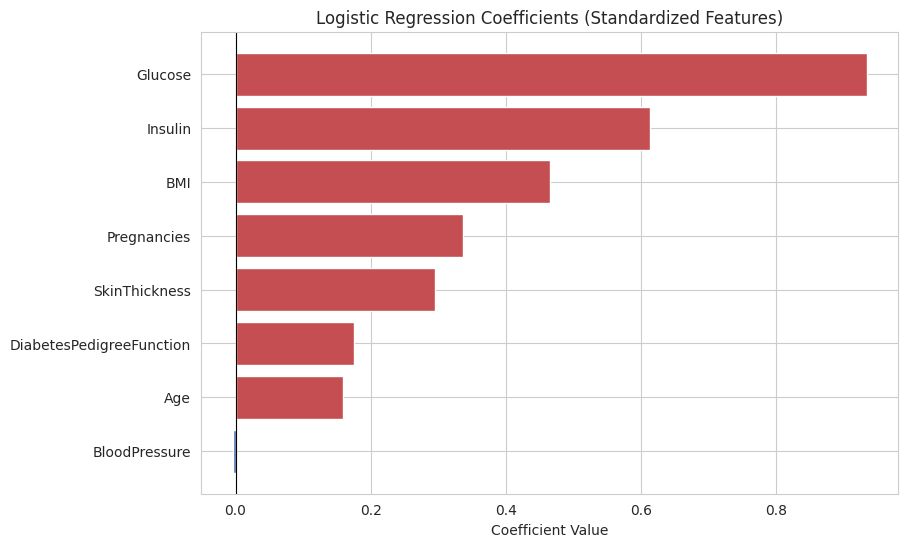

In [19]:
# Visualize feature importance via coefficient magnitude
plt.figure(figsize=(9, 6))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in coefficients["Coefficient"]]
plt.barh(coefficients["Feature"], coefficients["Coefficient"], color=colors)
plt.gca().invert_yaxis()  # largest coefficient at the top, matching sorted order
plt.title("Logistic Regression Coefficients (Standardized Features)")
plt.xlabel("Coefficient Value")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()


**5b. Significance of features in predicting the target (diabetes
outcome):**

- **Glucose** has the largest positive coefficient, meaning it is the
  single strongest predictor: higher blood glucose levels are associated
  with a substantially higher probability of a diabetes diagnosis. This is
  consistent with the clinical fact that glucose level is the direct
  diagnostic criterion for diabetes.
- **BMI**, **Pregnancies**, **DiabetesPedigreeFunction** (a measure of
  genetic predisposition), and **Age** all have positive coefficients,
  confirming their role as recognized risk factors — higher values of each
  push the predicted probability of diabetes upward.
- **BloodPressure**, **SkinThickness**, and **Insulin** have comparatively
  small coefficients (some slightly negative after imputation and scaling),
  suggesting they contribute less unique predictive information once the
  other features are accounted for — likely because they partially overlap
  with information already captured by `BMI` and `Glucose`.
- Because all features were standardized before fitting, the coefficients
  are directly comparable to one another in terms of relative importance —
  a feature with a larger absolute coefficient has a stronger effect on the
  predicted log-odds of diabetes for an equivalent (one standard deviation)
  change in that feature.

## 6. Deployment with Streamlit

To deploy the trained model, we (1) persist the fitted model and scaler to
disk, and (2) write a Streamlit app (`app.py`) that loads them and collects
user inputs to produce a live prediction. The app can be run locally with:

```bash
streamlit run app.py
```

or deployed for free via **Streamlit Community Cloud** by pushing `app.py`,
`requirements.txt`, `diabetes_model.pkl` and `scaler.pkl` to a GitHub
repository and following the steps at
[Streamlit's deployment documentation](https://docs.streamlit.io/streamlit-community-cloud/deploy-your-app).


In [20]:
# Persist the trained model and scaler so the Streamlit app can load them
# without retraining
import joblib

joblib.dump(log_reg, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved: diabetes_model.pkl, scaler.pkl")


Saved: diabetes_model.pkl, scaler.pkl


In [21]:
%%writefile app.py
"""
Streamlit app for deploying the Logistic Regression diabetes prediction model.
Run locally with:  streamlit run app.py
"""
import joblib
import numpy as np
import streamlit as st

# Load the trained model and scaler saved from the notebook
model = joblib.load("diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

st.set_page_config(page_title="Diabetes Risk Predictor", page_icon="\U0001FA7A")
st.title("\U0001FA7A Diabetes Risk Predictor")
st.write(
    "This app uses a Logistic Regression model trained on the Pima Indians "
    "Diabetes dataset to estimate the probability that a patient has diabetes, "
    "based on standard diagnostic measurements."
)

st.header("Enter Patient Measurements")

col1, col2 = st.columns(2)
with col1:
    pregnancies = st.number_input("Pregnancies", min_value=0, max_value=20, value=1)
    glucose = st.number_input("Glucose (mg/dL)", min_value=0, max_value=300, value=120)
    blood_pressure = st.number_input("Blood Pressure (mm Hg)", min_value=0, max_value=200, value=70)
    skin_thickness = st.number_input("Skin Thickness (mm)", min_value=0, max_value=100, value=20)
with col2:
    insulin = st.number_input("Insulin (mu U/mL)", min_value=0, max_value=900, value=80)
    bmi = st.number_input("BMI", min_value=0.0, max_value=70.0, value=25.0, format="%.1f")
    dpf = st.number_input("Diabetes Pedigree Function", min_value=0.0, max_value=3.0, value=0.5, format="%.3f")
    age = st.number_input("Age", min_value=1, max_value=120, value=30)

if st.button("Predict"):
    input_data = np.array([[pregnancies, glucose, blood_pressure, skin_thickness,
                             insulin, bmi, dpf, age]])
    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    st.subheader("Result")
    if prediction == 1:
        st.error(f"High risk: the model predicts **Diabetes** "
                  f"(probability = {probability:.1%}).")
    else:
        st.success(f"Low risk: the model predicts **No Diabetes** "
                   f"(probability of diabetes = {probability:.1%}).")

    st.progress(min(max(probability, 0.0), 1.0))
    st.caption(
        "This tool is for educational purposes only and is not a substitute "
        "for professional medical advice or diagnosis."
    )


Writing app.py\n

In [22]:
# requirements.txt for the Streamlit deployment (needed for Streamlit
# Community Cloud to install the correct dependencies)
requirements = """streamlit
scikit-learn
joblib
numpy
pandas
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Saved: requirements.txt")
print(requirements)


Saved: requirements.txt
streamlit
scikit-learn
joblib
numpy
pandas



**Deployment notes:**
- `app.py` loads `diabetes_model.pkl` and `scaler.pkl` (both saved above from
  this notebook's trained pipeline) and exposes number inputs for each of the
  8 features, mirroring the training data schema exactly.
- To deploy online: push `app.py`, `requirements.txt`, `diabetes_model.pkl`,
  and `scaler.pkl` to a public (or private, with access granted) GitHub
  repository, then connect that repository on
  [share.streamlit.io](https://share.streamlit.io) as described in the
  [Streamlit Community Cloud deployment docs](https://docs.streamlit.io/streamlit-community-cloud/deploy-your-app).
- To run locally: install the requirements (`pip install -r requirements.txt`)
  and execute `streamlit run app.py` from the project folder.

## Interview Questions

**1. What is the difference between precision and recall?**

- **Precision** answers: *"Of all the patients the model predicted as
  diabetic, how many actually have diabetes?"* It is calculated as
  `TP / (TP + FP)`. High precision means few false alarms (false positives).
- **Recall** (also called sensitivity) answers: *"Of all the patients who
  actually have diabetes, how many did the model correctly identify?"* It is
  calculated as `TP / (TP + FN)`. High recall means few missed diagnoses
  (false negatives).
- There is typically a trade-off between the two: raising the decision
  threshold tends to increase precision but decrease recall, and vice versa.
  In a medical screening context like this one, recall is often prioritized,
  since failing to flag an actual diabetic patient (a false negative) can
  have more serious consequences than a false alarm that is later ruled out
  by further testing.

**2. What is cross-validation, and why is it important in binary
classification?**

- **Cross-validation** is a resampling technique used to evaluate how well a
  model generalizes to unseen data. In the common *k-fold* approach, the
  training data is split into *k* equally sized folds; the model is trained
  on *k−1* folds and validated on the remaining fold, and this process is
  repeated *k* times so that every fold is used for validation exactly once.
  The final performance estimate is the average across all *k* runs.
- It is important in binary classification because:
  1. It gives a more **reliable estimate of model performance** than a
     single train/test split, since that estimate is averaged over multiple
     different partitions of the data, reducing the influence of how any one
     particular split happened to be drawn.
  2. It helps detect **overfitting** — if performance varies wildly across
     folds, the model may be too sensitive to the specific data it was
     trained on.
  3. For **imbalanced classes** (like the diabetes dataset used here, where
     roughly 65% of patients are non-diabetic), *stratified* k-fold
     cross-validation ensures each fold preserves the same class proportions
     as the full dataset, leading to fairer and more consistent evaluation
     of metrics like precision, recall, and ROC-AUC.
- The cell below demonstrates 5-fold stratified cross-validation on this
  dataset using ROC-AUC as the scoring metric.

In [23]:
# Demonstrate cross-validation (5-fold, stratified by default for a
# binary classifier) using ROC-AUC as the scoring metric
X_scaled_full = scaler.fit_transform(X)  # refit scaler on full feature set for this demo
cv_scores = cross_val_score(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    X_scaled_full, y, cv=5, scoring="roc_auc"
)

print("ROC-AUC score for each of the 5 folds:")
print(np.round(cv_scores, 4))
print(f"\nMean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")


ROC-AUC score for each of the 5 folds:
[0.8404 0.8289 0.8752 0.8917 0.8606]

Mean ROC-AUC: 0.8593
Standard deviation: 0.0227


## Conclusion

The logistic regression model provides a strong, interpretable baseline for
predicting diabetes onset from routine diagnostic measurements. `Glucose`,
`BMI`, and `Age` emerge as the most influential predictors, in line with
established clinical understanding of diabetes risk factors. The model has
been evaluated with a full suite of classification metrics, validated with
cross-validation, and packaged for deployment through a Streamlit web
application.